In [1]:
import glob
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
## PATH ##

path = Path('/mnt/sdb/scz_meta_analysis_processed/dge_signatures')

In [3]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')
adata_hvg = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_hvg.h5ad', backed='r')

adata.obsm = adata_hvg.obsm.copy()
adata.obsp = adata_hvg.obsp.copy()
adata.uns = adata_hvg.uns.copy()

# collect memory
del adata_hvg
gc.collect()

# read in cluster identites from hierarchical_clustering_scVI  
cluster_identities = pd.read_csv(path / 'iterative_clustering_table_plus_missing.csv',
                                 index_col=0)

del adata.obs['class']
adata.obs = adata.obs.merge(cluster_identities, left_index=True, right_index=True, how='left')

In [4]:
## Class #

class_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/class/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    dge = dge[(dge['adj.P.Val'] < 0.05) & (dge['logFC'] > 1)].sort_values(by='AveExpr', ascending=False)
    class_dge_list.append(dge)

class_dges = pd.concat(class_dge_list, axis=0)

class_dges = class_dges[~pd.Series(class_dges.index).str.contains('ENSG').values]

In [5]:
## Subclass #

subclass_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subclass/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    dge = dge[(dge['adj.P.Val'] < 0.05) & (dge['logFC'] > 1)].sort_values(by='AveExpr', ascending=False)
#    dge = dge[dge['AveExpr'] > 4]
    subclass_dge_list.append(dge)

subclass_dges = pd.concat(subclass_dge_list, axis=0)

subclass_dges = subclass_dges[~pd.Series(subclass_dges.index).str.contains('ENSG').values]

In [6]:
## Subtypes ##

subtype_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subtype/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    dge = dge[(dge['adj.P.Val'] < 0.05) & (dge['logFC'] > 1)].sort_values(by='AveExpr', ascending=False)
    subtype_dge_list.append(dge)

subtypes_dges = pd.concat(subtype_dge_list, axis=0)

subtypes_dges = subtypes_dges[~pd.Series(subtypes_dges.index).str.contains('ENSG').values]

In [7]:
## Identify Troublesome Clusters ##

for i in range(len(subtype_dge_list)):
    try:
        print(subtype_dge_list[i]['subtype'][0], subtype_dge_list[i].shape[0])
    except:
        troublesome_file_path = glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subtype/DE_*')[i]
        troublesome_file = troublesome_file_path.split('/')[-1].strip('.csv').strip('DE_')
        count = (adata.obs['subtype'] == troublesome_file).sum()
        print(f"DGE failed for {troublesome_file} with {count} DGEs")

1_1_1 716
1_1_1_3 969
1_2_5 2028
1_1_4 300
2_2_1 226
2_4_2 176
1_4_3 275
1_4_2 137
1_1_3 349
2_4_4 285
2_1_1 903
1_2_4 130
2_4_1 22
1_1_4_4 2246
1_4_1 351
1_2_3 284
1_5_2 77
1_2_2 156
2_2_5 1146
1_3_3 297
DGE failed for 1_5_3 with 75 DGEs
1_3_4 327
2_1_2 219
1_4_4 142
1_1_2 543
1_1_6 2725
1_2_1 1351
2_2_4 107
1_3_2 623
1_3_1 49
1_1_4_11 4264
2_3_2 165
2_1_2_2 476
2_2_3 131
2_3_3 337
2_1_4 717
2_4_3 202
2_2_2 204
1_5_1 88
2_1_3 195
1_1_5 368
2_3_1 81


/tmp/ipykernel_4073636/3794337784.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(subtype_dge_list[i]['subtype'][0], subtype_dge_list[i].shape[0])


In [8]:
## Identify Subtypes Where Dreamlet Dropped High Percentage of Samples (Run_Donor_Samples) ##

dropped_samples = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subtype/dropped_samples_log.csv')
dropped_samples['total'].fillna(257.0, inplace=True)
dropped_samples['dropped'].fillna(0, inplace=True)
dropped_samples['percentage'] = dropped_samples['dropped']/dropped_samples['total']
dropped_samples['high_drop_percentage'] = dropped_samples['percentage'] > 0.5

<Axes: xlabel='percentage', ylabel='Count'>

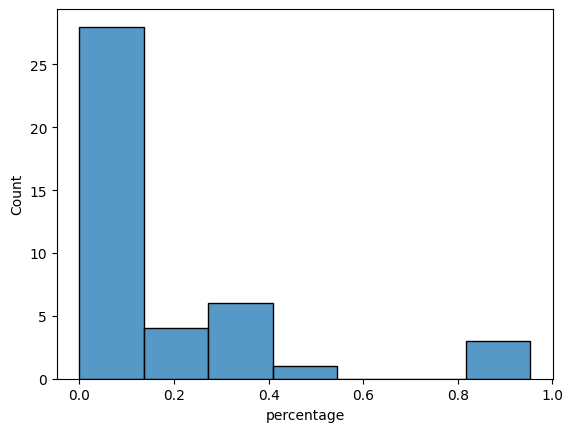

In [9]:
## Distribution of Dropped Samples ##

sns.histplot(dropped_samples['percentage'])

In [11]:
adata[adata.obs['subclass'] == '1_5'].obs[['subtype', 'Manuscript']].value_counts().sort_index()

subtype  Manuscript
1_5_1    Notaras         6
         Purcell        41
         Rao             2
         Sebastian       8
         Walsh         345
1_5_2    Notaras         6
         Purcell         2
         Rao             2
         Sebastian      39
         Walsh         332
1_5_3    Purcell        63
         Shin           12
Name: count, dtype: int64

In [12]:
adata[adata.obs['subclass'] == '1_5'].obs[['subclass', 'Manuscript']].value_counts().sort_index()

subclass  Manuscript
1_5       Notaras        12
          Purcell       106
          Rao             4
          Sebastian      47
          Shin           12
          Walsh         677
Name: count, dtype: int64

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


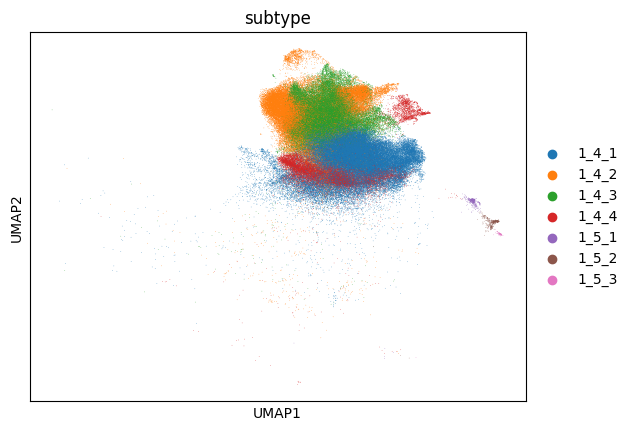

In [13]:
sc.pl.umap(adata[adata.obs['subclass'].str.contains('1_4|1_5')],
           color='subtype', layer='log1p_norm', ncols=2)

In [14]:
## Re-merge ##

# remerge 1_5_1, 1_5_2, 1_5_3
adata.obs['subtypes_remerged'] = adata.obs['subtype']
adata.obs.loc[(adata.obs['subclass'] == '1_5'), 'subtypes_remerged'] = '1_5'

In [15]:
## Write Re-Merged Clusters ##

iterative_clustering_table = adata.obs[['class', 'subclass', 'subtype', 'subtypes_remerged']]

iterative_clustering_table.to_csv(path / 'iterative_clustering_table_plus_missing_post_merge.csv', index=True)

In [16]:
## Save for Dreamlet ##

adata.obs['Sample Name'] = adata.obs['Sample Name'].astype('str')
adata.obs['Run_Donor'] = adata.obs['Run'].astype('str') + '_' + adata.obs['Donor'].astype('str')
adata.obs['Run_Donor_Sample'] = adata.obs['Run_Donor'] + '_' + adata.obs['Sample Name']
adata.X = adata.layers['raw_counts']
del adata.layers

adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/one_versus_all_for_dreamlet_remerged.h5ad')